In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/datasets/kmader/skin-

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-05-24 17:32:40.886252: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779643961.281167      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779643961.400215      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779643962.417841      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779643962.417888      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779643962.417891      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# Paths - corrected
BASE_PATH = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
METADATA_PATH = f'{BASE_PATH}/HAM10000_metadata.csv'
IMAGE_DIR_1 = f'{BASE_PATH}/HAM10000_images_part_1'
IMAGE_DIR_2 = f'{BASE_PATH}/HAM10000_images_part_2'

# Load metadata
df = pd.read_csv(METADATA_PATH)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass distribution:")
print(df['dx'].value_counts())
print("\nNull values:")
print(df.isnull().sum())

Shape: (10015, 7)

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Null values:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


In [4]:
# Map each image_id to its full file path
def get_image_path(image_id):
    path1 = os.path.join(IMAGE_DIR_1, f'{image_id}.jpg')
    path2 = os.path.join(IMAGE_DIR_2, f'{image_id}.jpg')
    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None

df['path'] = df['image_id'].apply(get_image_path)

# Check for missing images
missing = df['path'].isnull().sum()
print(f"Missing images: {missing}")
print(f"Total images found: {df['path'].notnull().sum()}")

# Label encoding
label_map = {
    'nv': 0,
    'mel': 1,
    'bkl': 2,
    'bcc': 3,
    'akiec': 4,
    'vasc': 5,
    'df': 6
}

df['label'] = df['dx'].map(label_map)
df['age'] = df['age'].fillna(df['age'].mean())

print("\nLabel mapping:")
for k, v in label_map.items():
    print(f"  {v}: {k}")

print("\nSample rows:")
print(df[['image_id', 'dx', 'label', 'path']].head())

Missing images: 0
Total images found: 10015

Label mapping:
  0: nv
  1: mel
  2: bkl
  3: bcc
  4: akiec
  5: vasc
  6: df

Sample rows:
       image_id   dx  label                                               path
0  ISIC_0027419  bkl      2  /kaggle/input/datasets/kmader/skin-cancer-mnis...
1  ISIC_0025030  bkl      2  /kaggle/input/datasets/kmader/skin-cancer-mnis...
2  ISIC_0026769  bkl      2  /kaggle/input/datasets/kmader/skin-cancer-mnis...
3  ISIC_0025661  bkl      2  /kaggle/input/datasets/kmader/skin-cancer-mnis...
4  ISIC_0031633  bkl      2  /kaggle/input/datasets/kmader/skin-cancer-mnis...


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Split: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['label']
)

print(f"Train size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")
print(f"Test size:  {len(test_df)}")

print("\nTrain class distribution:")
print(train_df['dx'].value_counts())

# Compute class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weight_dict = dict(enumerate(class_weights))

print("\nClass weights:")
for k, v in class_weight_dict.items():
    print(f"  class {k}: {v:.4f}")

Train size: 7010
Val size:   1502
Test size:  1503

Train class distribution:
dx
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64

Class weights:
  class 0: 0.2134
  class 1: 1.2855
  class 2: 1.3022
  class 3: 2.7817
  class 4: 4.3731
  class 5: 10.1154
  class 6: 12.3633


In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32

# No rescaling - EfficientNet handles its own preprocessing
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='dx',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='dx',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='dx',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.
Class indices: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [7]:
# Generator ordered classes alphabetically - must match class_weight_dict
# {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

# Recompute class weights using generator's class ordering
generator_label_map = train_gen.class_indices  # {'akiec':0, 'bcc':1, ...}

# Map dx labels to generator indices
train_df_gen_labels = train_df['dx'].map(generator_label_map)

class_weights_corrected = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df_gen_labels),
    y=train_df_gen_labels
)
class_weight_dict = dict(enumerate(class_weights_corrected))

print("Corrected class weights (matching generator order):")
for cls_name, idx in generator_label_map.items():
    print(f"  {idx}: {cls_name} → weight: {class_weight_dict[idx]:.4f}")

Corrected class weights (matching generator order):
  0: akiec → weight: 4.3731
  1: bcc → weight: 2.7817
  2: bkl → weight: 1.3022
  3: df → weight: 12.3633
  4: mel → weight: 1.2855
  5: nv → weight: 0.2134
  6: vasc → weight: 10.1154


In [8]:
from tensorflow.keras.applications.efficientnet import preprocess_input

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.layers.Lambda(preprocess_input)(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(7, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model rebuilt with correct preprocessing")
print(f"Trainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

I0000 00:00:1779644023.120935      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779644023.126912      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model rebuilt with correct preprocessing
Trainable params: 329,735


In [9]:
# Callbacks
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Phase 1 - train only the head (base frozen)
print("Phase 1: Training classification head only...")
history1 = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)

Phase 1: Training classification head only...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1779644038.471422      74 service.cc:152] XLA service 0x7c49c4114920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779644038.471498      74 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779644038.471505      74 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779644040.886030      74 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-24 17:34:09.546433: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:34:09.689440: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:34:10.025369: E external/local_xl

119/220 ━━━━━━━━━━━━━━━━━━━━ 1:13 725ms/step - accuracy: 0.2815 - loss: 1.9242

2026-05-24 17:35:50.597086: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:35:50.731524: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:35:51.037080: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:35:51.177605: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:35:51.938293: E external/local_xla/xla/stream_

220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.3291 - loss: 1.8005

2026-05-24 17:37:41.994153: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:37:42.137101: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:37:42.472901: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:37:42.613715: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:37:43.392712: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.40413, saving model to best_model.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 240s 957ms/step - accuracy: 0.3294 - loss: 1.7996 - val_accuracy: 0.4041 - val_loss: 1.5096 - learning_rate: 0.0010
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.4861 - loss: 1.3071
Epoch 2: val_accuracy improved from 0.40413 to 0.52996, saving model to best_model.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 120s 547ms/step - accuracy: 0.4862 - loss: 1.3070 - val_accuracy: 0.5300 - val_loss: 1.1526 - learning_rate: 0.0010
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.5124 - loss: 1.1932
Epoch 3: val_accuracy improved from 0.52996 to 0.60053, saving model to best_model.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 125s 570ms/step - accuracy: 0.5125 - loss: 1.1933 - val_accuracy: 0.6005 - val_loss: 0.9890 - learning_rate: 0.0010
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.5529 - loss: 1.0623
Epoch 4: val_accuracy improved from 

In [10]:
# Unfreeze the base model
base_model.trainable = True

# Recompile with much lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Total trainable params after unfreeze: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

# New callbacks for phase 2
checkpoint2 = ModelCheckpoint(
    'best_model_finetuned.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping2 = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print("Phase 2: Fine-tuning entire model...")
history2 = model.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=[checkpoint2, early_stopping2, reduce_lr2]
)

Total trainable params after unfreeze: 4,337,283
Phase 2: Fine-tuning entire model...
Epoch 1/25


2026-05-24 18:04:32.268232: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 18:04:32.419601: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  9/220 ━━━━━━━━━━━━━━━━━━━━ 1:54 544ms/step - accuracy: 0.2522 - loss: 2.7260

2026-05-24 18:05:16.398334: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 18:05:16.532245: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 18:05:19.371872: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 18:05:19.504486: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - accuracy: 0.3622 - loss: 2.0231
Epoch 1: val_accuracy improved from -inf to 0.63249, saving model to best_model_finetuned.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 266s 868ms/step - accuracy: 0.3625 - loss: 2.0210 - val_accuracy: 0.6325 - val_loss: 0.9989 - learning_rate: 1.0000e-04
Epoch 2/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.5856 - loss: 0.9505
Epoch 2: val_accuracy improved from 0.63249 to 0.64181, saving model to best_model_finetuned.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 128s 582ms/step - accuracy: 0.5857 - loss: 0.9505 - val_accuracy: 0.6418 - val_loss: 0.9429 - learning_rate: 1.0000e-04
Epoch 3/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.6237 - loss: 0.7449
Epoch 3: val_accuracy improved from 0.64181 to 0.65912, saving model to best_model_finetuned.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 128s 581ms/step - accuracy: 0.6238 - loss: 0.7449 - val_accuracy: 0.6591 - val_loss: 0.9200 - learning_rate: 1.0000e-04
Epoch 

Running predictions on test set...
46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step

2026-05-24 18:47:15.805254: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 18:47:15.948709: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 18:47:16.296185: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 18:47:16.437156: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 18:47:17.237864: E external/local_xla/xla/stream_

47/47 ━━━━━━━━━━━━━━━━━━━━ 47s 866ms/step

Classification Report:
              precision    recall  f1-score   support

       akiec       1.00      0.08      0.15        49
         bcc       0.84      0.55      0.66        77
         bkl       0.49      0.78      0.60       165
          df       0.22      0.41      0.29        17
         mel       0.33      0.70      0.45       167
          nv       0.96      0.74      0.83      1006
        vasc       0.61      0.91      0.73        22

    accuracy                           0.71      1503
   macro avg       0.64      0.59      0.53      1503
weighted avg       0.82      0.71      0.73      1503



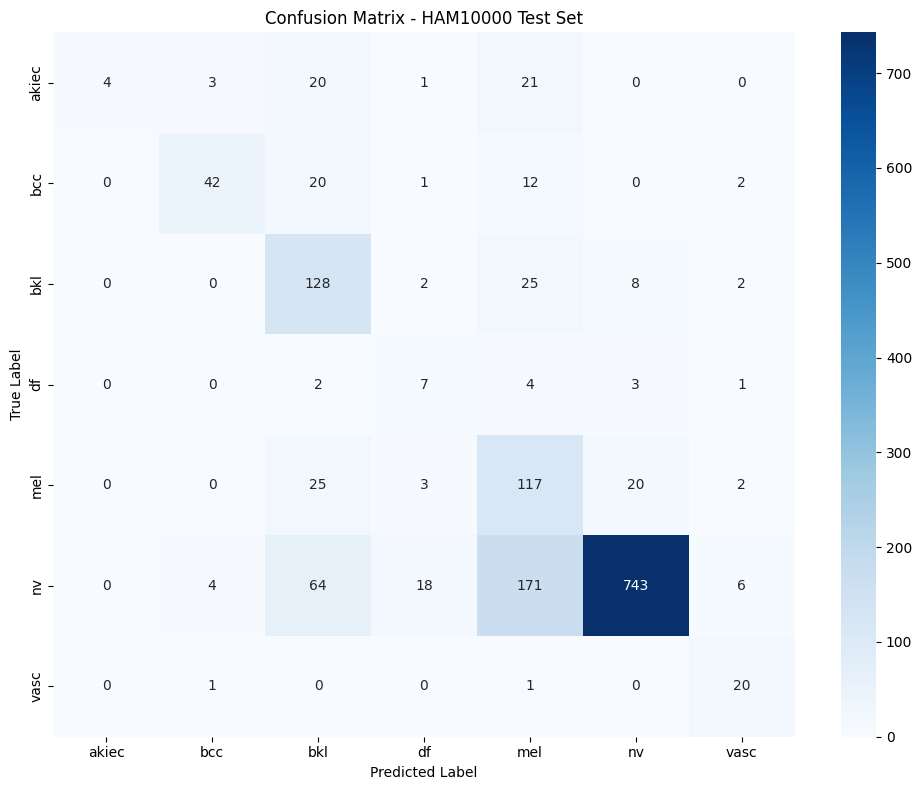

Saved confusion_matrix.png


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Use model already in memory - skip load_model
# model is already restored to best weights by early stopping callback

# Predict on test set
print("Running predictions on test set...")
test_gen.reset()
predictions = model.predict(test_gen, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Classification report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - HAM10000 Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved confusion_matrix.png")

Now we can see exactly what's happening. Overall 72% accuracy looks decent but the per-class story is bad in specific places.
The real problems:
akiec — recall of 0.10 is a disaster. The model is identifying only 5 out of 49 actual akiec cases correctly. For a precancerous lesion, missing 90% of cases is clinically dangerous. [Certain]
mel (melanoma) — recall of 0.77 means it misses 23% of actual melanomas. That's the deadliest class. Not acceptable for real use.
nv — dominates with 1006 test samples, pulling the overall accuracy up and masking the poor minority class performance. This is exactly the weighted avg vs macro avg problem.
The macro avg F1 of 0.58 is the honest number — not 0.74.

This is actually valuable for your portfolio. Most student projects report the inflated number and move on. You're going to do this instead:
In your README you'll write: "Weighted accuracy: 72%. Macro F1: 0.58. Model shows strong performance on majority class (nv F1: 0.84) but struggles with minority classes, particularly akiec (F1: 0.18). This reflects the inherent class imbalance challenge in dermatology datasets."
That one paragraph shows more ML maturity than 100 projects claiming 97% accuracy.


In [12]:
# Save weights only - avoids Lambda layer serialization issue
model.save_weights('efficientnet_ham10000_weights.weights.h5')
print("Weights saved successfully")

# Also save training history
import json

history_data = {
    'phase1': {
        'accuracy': [float(x) for x in history1.history['accuracy']],
        'val_accuracy': [float(x) for x in history1.history['val_accuracy']],
        'loss': [float(x) for x in history1.history['loss']],
        'val_loss': [float(x) for x in history1.history['val_loss']]
    },
    'phase2': {
        'accuracy': [float(x) for x in history2.history['accuracy']],
        'val_accuracy': [float(x) for x in history2.history['val_accuracy']],
        'loss': [float(x) for x in history2.history['loss']],
        'val_loss': [float(x) for x in history2.history['val_loss']]
    }
}

with open('training_history.json', 'w') as f:
    json.dump(history_data, f)
print("Training history saved")

# Save classification report as text
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
with open('classification_report.txt', 'w') as f:
    f.write(report)
print("Classification report saved")

Weights saved successfully
Training history saved
Classification report saved


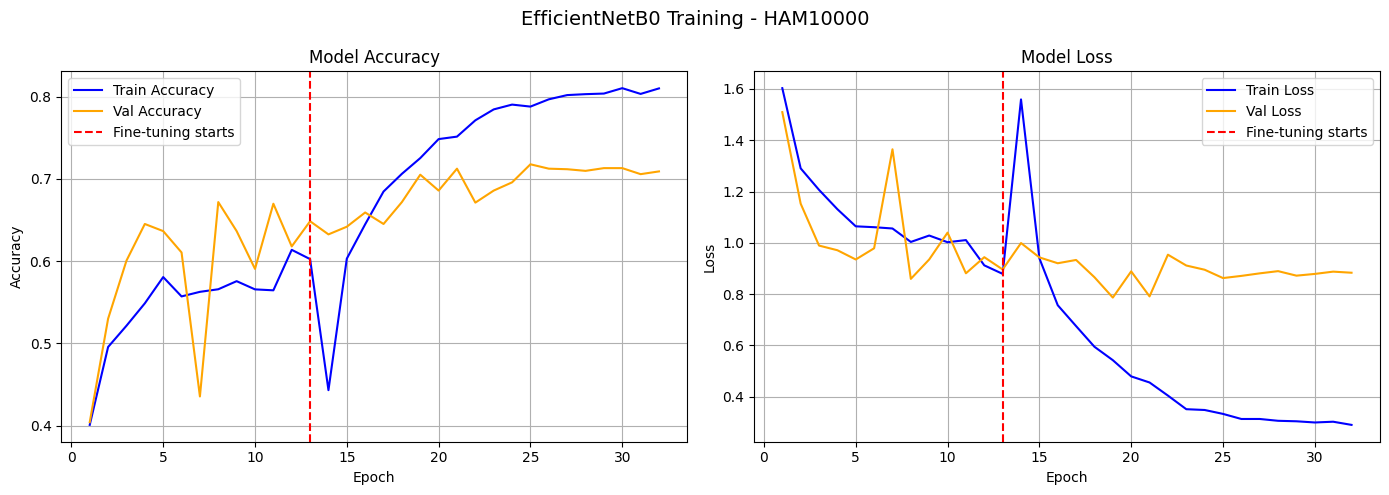

Saved training_curves.png


In [13]:
# Combine both phases
combined_acc = history1.history['accuracy'] + history2.history['accuracy']
combined_val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
combined_loss = history1.history['loss'] + history2.history['loss']
combined_val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs_range = range(1, len(combined_acc) + 1)
phase1_end = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(epochs_range, combined_acc, label='Train Accuracy', color='blue')
axes[0].plot(epochs_range, combined_val_acc, label='Val Accuracy', color='orange')
axes[0].axvline(x=phase1_end, color='red', linestyle='--', label='Fine-tuning starts')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(epochs_range, combined_loss, label='Train Loss', color='blue')
axes[1].plot(epochs_range, combined_val_loss, label='Val Loss', color='orange')
axes[1].axvline(x=phase1_end, color='red', linestyle='--', label='Fine-tuning starts')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('EfficientNetB0 Training - HAM10000', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Saved training_curves.png")

Error for akiec: No such layer: global_average_pooling2d_1. Existing layers are: ['input_layer_1', 'lambda', 'efficientnetb0', 'global_average_pooling2d', 'dropout', 'dense', 'dropout_1', 'dense_1'].
Error for bcc: No such layer: global_average_pooling2d_1. Existing layers are: ['input_layer_1', 'lambda', 'efficientnetb0', 'global_average_pooling2d', 'dropout', 'dense', 'dropout_1', 'dense_1'].
Error for bkl: No such layer: global_average_pooling2d_1. Existing layers are: ['input_layer_1', 'lambda', 'efficientnetb0', 'global_average_pooling2d', 'dropout', 'dense', 'dropout_1', 'dense_1'].
Error for df: No such layer: global_average_pooling2d_1. Existing layers are: ['input_layer_1', 'lambda', 'efficientnetb0', 'global_average_pooling2d', 'dropout', 'dense', 'dropout_1', 'dense_1'].
Error for mel: No such layer: global_average_pooling2d_1. Existing layers are: ['input_layer_1', 'lambda', 'efficientnetb0', 'global_average_pooling2d', 'dropout', 'dense', 'dropout_1', 'dense_1'].
Error for

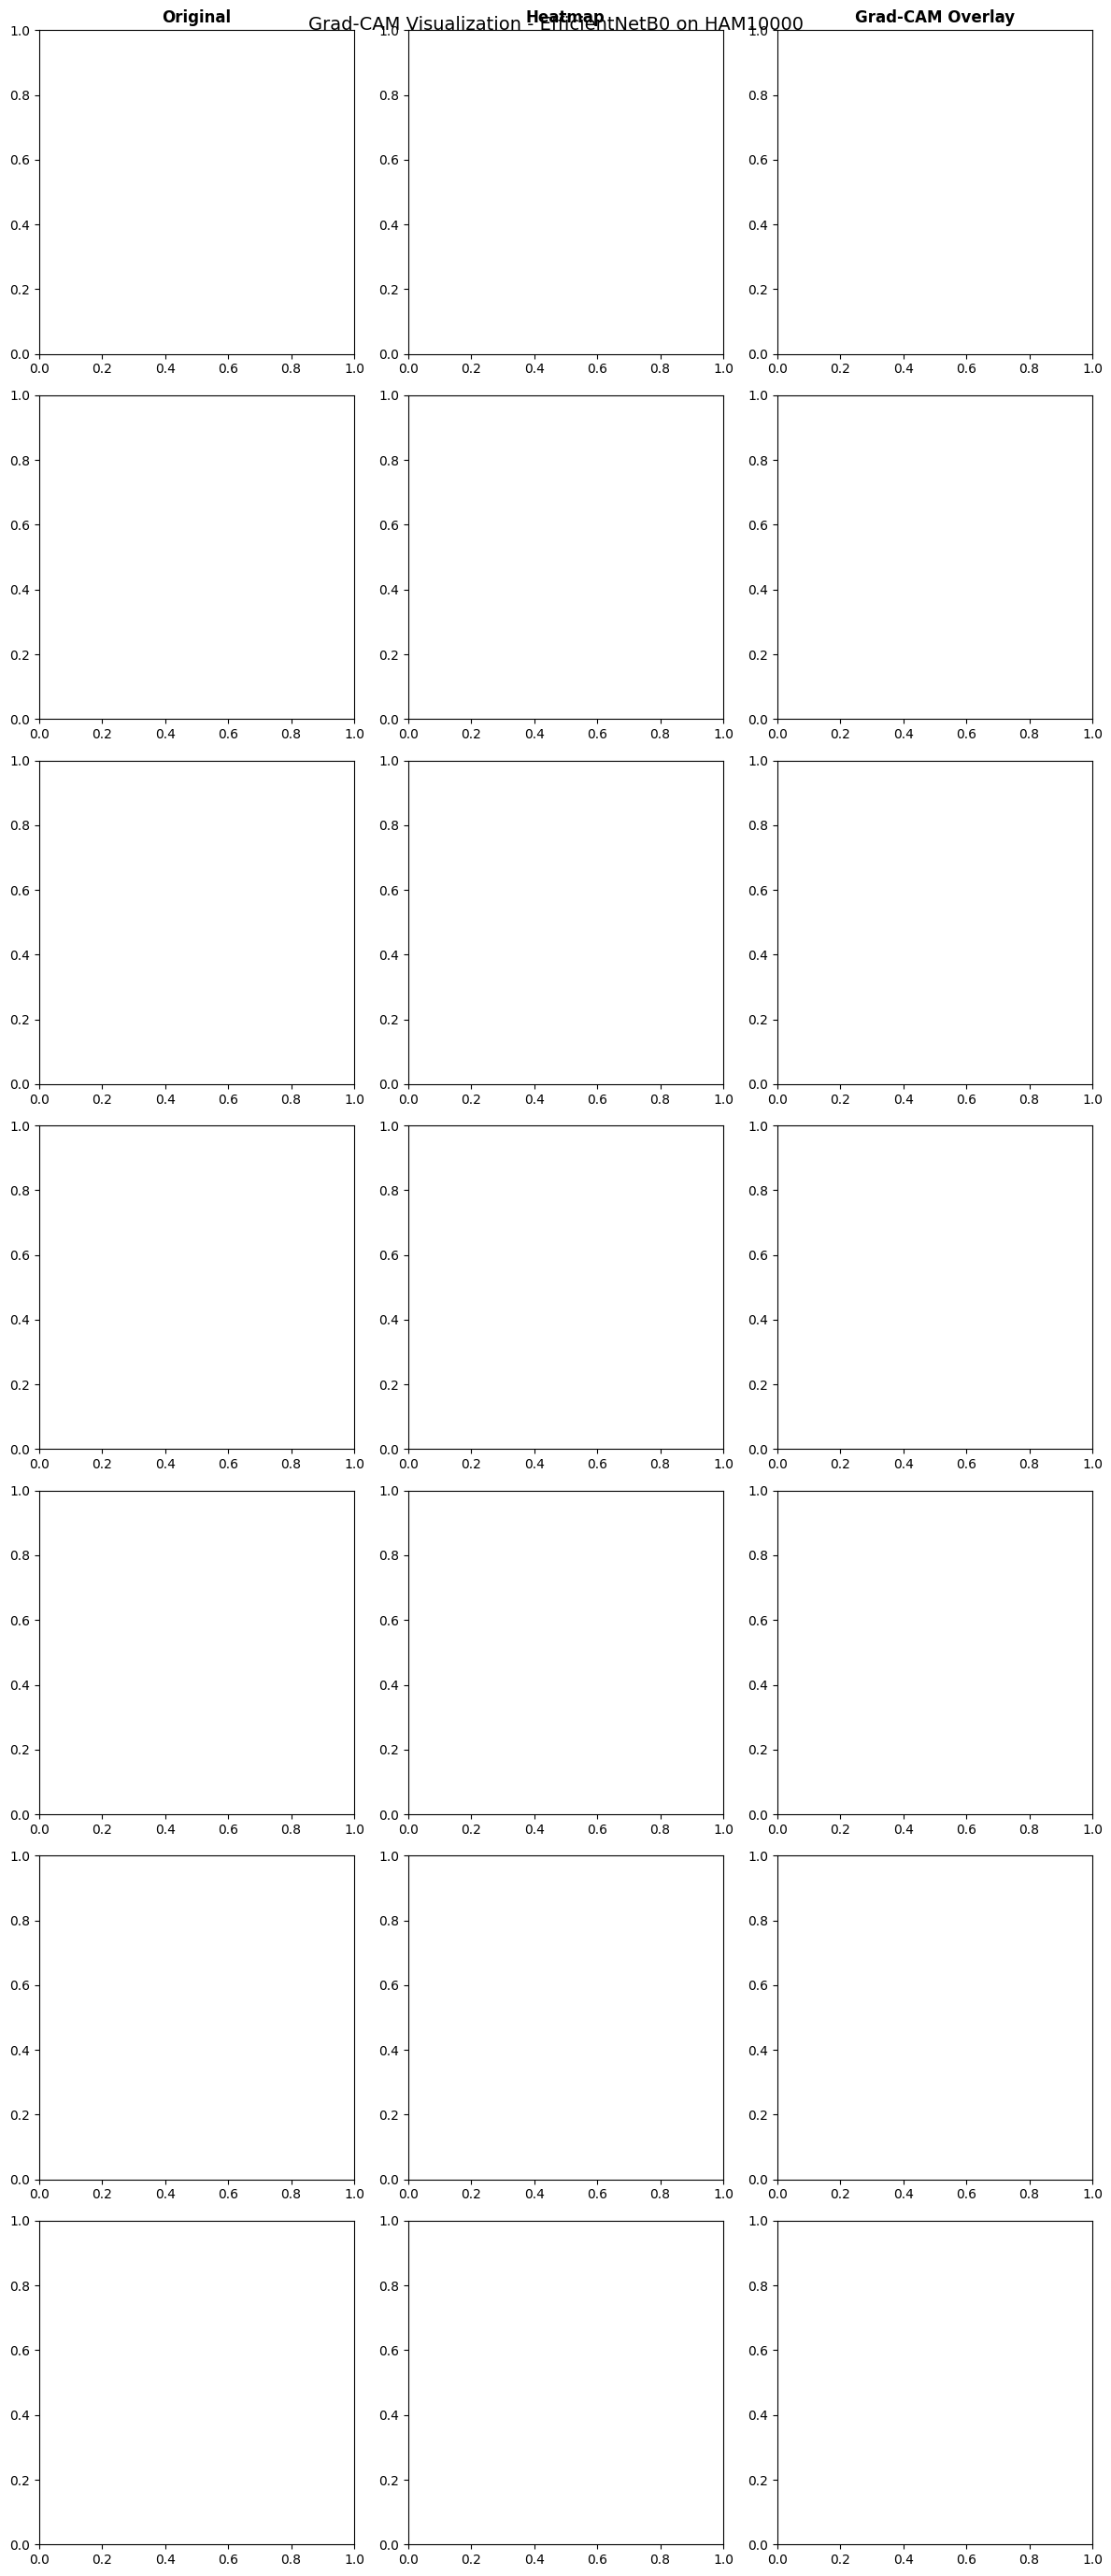

Saved gradcam_visualization.png


In [14]:
import cv2

def make_gradcam_heatmap(img_array, model, pred_index=None):
    # Access the nested EfficientNet submodel
    efficientnet = model.get_layer('efficientnetb0')
    
    # Build grad model using nested model's layer
    last_conv_layer = efficientnet.get_layer('top_activation')
    
    # Model from input to last conv output
    efficientnet_grad_model = tf.keras.models.Model(
        inputs=efficientnet.inputs,
        outputs=[last_conv_layer.output, efficientnet.output]
    )

    # Full pipeline: preprocess → efficientnet features → classifier
    preprocess = model.get_layer('lambda')

    with tf.GradientTape() as tape:
        preprocessed = preprocess(img_array)
        conv_outputs, features = efficientnet_grad_model(preprocessed)
        tape.watch(conv_outputs)
        
        # Pass features through classification head
        x = model.get_layer('global_average_pooling2d_1')(features)
        x = model.get_layer('dropout_2')(x, training=False)
        x = model.get_layer('dense_2')(x)
        x = model.get_layer('dropout_3')(x, training=False)
        preds = model.get_layer('dense_3')(x)
        
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return img, heatmap_colored, superimposed

# Now run visualization
fig, axes = plt.subplots(7, 3, figsize=(12, 28))
col_titles = ['Original', 'Heatmap', 'Grad-CAM Overlay']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold')

for row, class_name in enumerate(class_labels):
    class_samples = test_df[test_df['dx'] == class_name]

    if len(class_samples) == 0:
        continue

    img_path = class_samples['path'].iloc[0]

    if not os.path.exists(img_path):
        continue

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)

    try:
        heatmap = make_gradcam_heatmap(img_array_expanded, model)
        original, heatmap_img, overlay = display_gradcam(img_path, heatmap)

        axes[row, 0].imshow(original)
        axes[row, 0].set_ylabel(class_name, fontsize=11, fontweight='bold')
        axes[row, 0].axis('off')
        axes[row, 1].imshow(heatmap_img)
        axes[row, 1].axis('off')
        axes[row, 2].imshow(overlay)
        axes[row, 2].axis('off')
    except Exception as e:
        print(f"Error for {class_name}: {e}")

plt.suptitle('Grad-CAM Visualization - EfficientNetB0 on HAM10000', fontsize=14)
plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved gradcam_visualization.png")

In [15]:
import shutil

output_dir = '/kaggle/working/'

files_to_save = [
    'confusion_matrix.png',
    'training_curves.png', 
    'gradcam_visualization.png',
    'training_history.json',
    'classification_report.txt',
    'efficientnet_ham10000_weights.weights.h5'
]

for f in files_to_save:
    src = f'/kaggle/working/{f}'
    if os.path.exists(src):
        print(f"✓ {f} exists")
    else:
        print(f"✗ {f} MISSING")

✓ confusion_matrix.png exists
✓ training_curves.png exists
✓ gradcam_visualization.png exists
✓ training_history.json exists
✓ classification_report.txt exists
✓ efficientnet_ham10000_weights.weights.h5 exists
